# Logistic cofficients

###  Interpreting Logistic Regression Coefficients

In this step, we extract the learned coefficients from our trained logistic regression models to understand which features most strongly influence each health condition.

- Positive coefficients ➜ Increase likelihood of condition ("Yes")
- Negative coefficients ➜ Decrease likelihood of condition
- Features are ranked by absolute value of their coefficients

This helps us identify the **most influential predictors** for each disease risk in interpretable terms.


In [1]:
import os
import pandas as pd

# --- Path Config ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
STATS_DIR = os.path.join(OUTPUTS_DIR, "statistics")
PLOTS_DIR = os.path.join(OUTPUTS_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUTS_DIR, "metrics")

# Make sure subfolders exist
os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

part15_metrics_dir = os.path.join(METRICS_DIR, "part15_coefficients")
os.makedirs(part15_metrics_dir, exist_ok=True)

part15_plots_dir = os.path.join(PLOTS_DIR, "part15_coefficients")
os.makedirs(part15_plots_dir, exist_ok=True)



In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

def extract_logistic_coefficients(model_path, preprocessor_path, output_csv, plot_title=None, plot_path=None, top_n=7):
    """
    Extracts coefficients from a saved logistic regression model and plots + saves them.

    Parameters:
    - model_path (str): Path to saved model .pkl file
    - preprocessor_path (str): Path to saved preprocessor .pkl file
    - output_csv (str): Output path to save coefficients table
    - plot_title (str): Plot title for bar chart
    - plot_path (str): If provided, saves plot as image
    - top_n (int): Top N features to plot based on absolute coefficient
    """
    # Load model and preprocessor
    model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)

    # Extract encoded feature names
    ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(
        preprocessor.transformers[0][2]
    )
    
    # Get coefficients
    coefficients = model.named_steps['model'].coef_[0]
    coef_df = pd.DataFrame({
        'Feature': ohe_features,
        'Coefficient': coefficients,
        'Abs_Coefficient': abs(coefficients)
    })

    # Sort and save CSV
    coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
    coef_df_sorted.to_csv(output_csv, index=False)

    # Plot Top N features
    top_features = coef_df_sorted.head(top_n)
    plt.figure(figsize=(10, 6))

    colors = ['orange' if x > 0 else 'teal' for x in top_features['Coefficient']]
    #plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)

    wrapped_labels = [label.replace("_", " ").replace(" - ", "\n").replace(" (", "\n(") for label in top_features['Feature']]
    plt.barh(wrapped_labels, top_features['Coefficient'], color=colors)



    #plt.barh(top_features['Feature'], top_features['Coefficient'], color='teal')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(plot_title or 'Top Logistic Regression Features')
    plt.xlabel('Coefficient (Log-Odds)')
    plt.tight_layout()
    plt.gca().invert_yaxis()
    if plot_path:
        plt.savefig(plot_path)
    plt.show()

    return coef_df_sorted


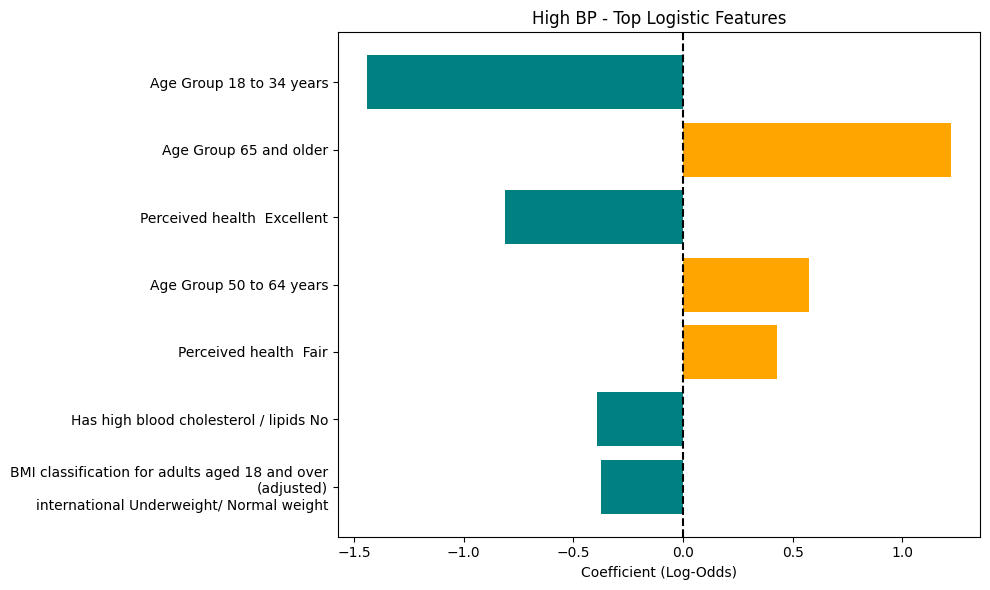

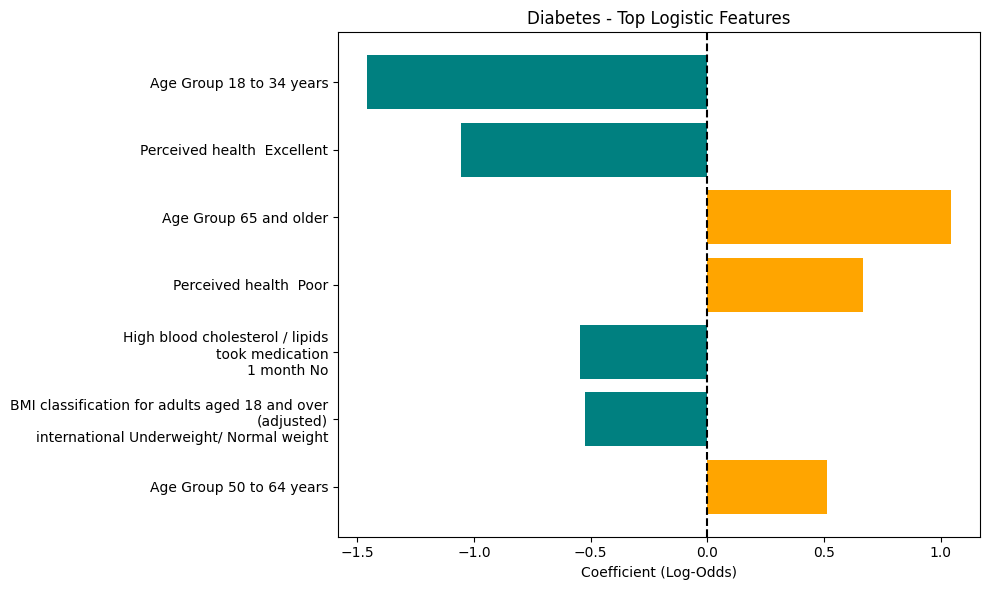

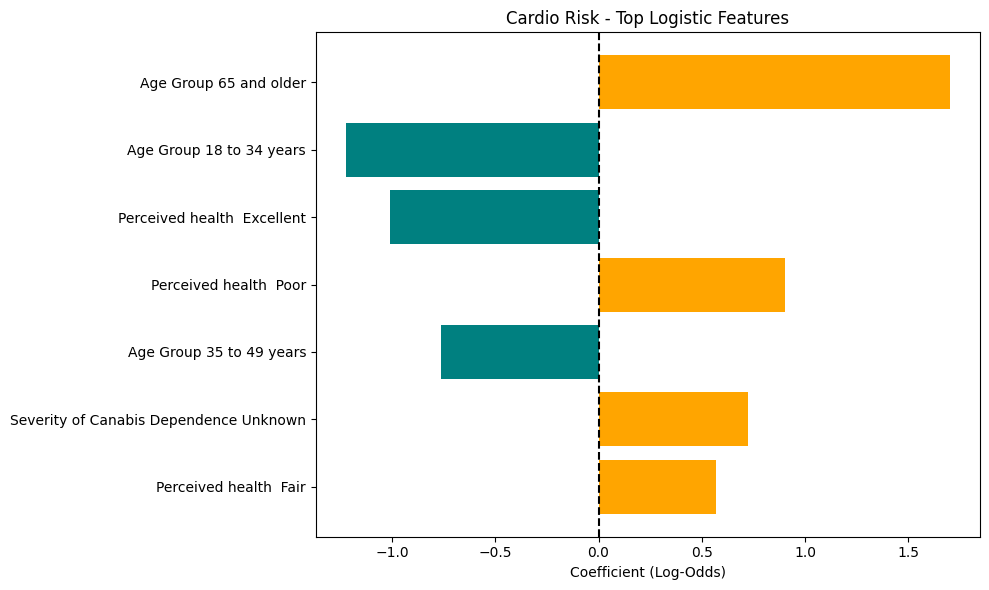

,Feature,Coefficient,Abs_Coefficient
3,Age Group_65 and older,1.701111,1.701111
0,Age Group_18 to 34 years,-1.223254,1.223254
40,Perceived health _Excellent,-1.007982,1.007982
43,Perceived health _Poor,0.902119,0.902119
1,Age Group_35 to 49 years,-0.762169,0.762169
...,...,...,...
55,Satisfaction with life in general _Very Satisfied,0.007717,0.007717
61,Seasonal flu shot - last time_Less than 1 year...,0.006073,0.006073
85,"Has an anxiety disorder (phobia, OCD, panic)_No",0.005850,0.005850
42,Perceived health _Good,0.003904,0.003904


In [3]:
# High Blood Pressure
extract_logistic_coefficients(
    model_path=os.path.join(METRICS_DIR, "part14_final_models", "model_highbp.pkl"),
    preprocessor_path=os.path.join(METRICS_DIR, "part14_final_models", "preprocessor_highbp.pkl"),
    output_csv=os.path.join(part15_metrics_dir, "logreg_coefficients_highbp.csv"),
    plot_title="High BP - Top Logistic Features",
    plot_path=os.path.join(part15_plots_dir, "logreg_plot_highbp.png")
)


# Diabetes
extract_logistic_coefficients(
    model_path=os.path.join(METRICS_DIR, "part14_final_models", "model_diabetes.pkl"),
    preprocessor_path=os.path.join(METRICS_DIR, "part14_final_models", "preprocessor_diabetes.pkl"),
    output_csv=os.path.join(part15_metrics_dir, "logreg_coefficients_diabetes.csv"),
    plot_title="Diabetes - Top Logistic Features",
    plot_path=os.path.join(part15_plots_dir, "logreg_plot_diabetes.png")
)

# Cardiovascular
extract_logistic_coefficients(
    model_path=os.path.join(METRICS_DIR, "part14_final_models", "model_cardio.pkl"),
    preprocessor_path=os.path.join(METRICS_DIR, "part14_final_models", "preprocessor_cardio.pkl"),
    output_csv=os.path.join(part15_metrics_dir, "logreg_coefficients_cardio.csv"),
    plot_title="Cardio Risk - Top Logistic Features",
    plot_path=os.path.join(part15_plots_dir, "logreg_plot_cardio.png")
)
